In [8]:
# ============================================
# RANDOM FOREST - CUSTOMER CHURN PREDICTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

# ============================================
# 1. Data Loading and Initial Exploration
# ============================================

# Placeholder for data loading.
# You'll need to upload your dataset (e.g., 'customer_churn.csv')
# or modify this line to load from another source.
try:
    df = pd.read_csv('customer_churn.csv')
    print("\nDataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'customer_churn.csv' not found. Please upload your dataset or provide the correct path.")
    # Create a dummy DataFrame for demonstration if file not found
    data = {
        'customerID': [f'C{i:05d}' for i in range(100)],
        'gender': np.random.choice(['Male', 'Female'], 100),
        'SeniorCitizen': np.random.randint(0, 2, 100),
        'Partner': np.random.choice(['Yes', 'No'], 100),
        'Dependents': np.random.choice(['Yes', 'No'], 100),
        'tenure': np.random.randint(1, 72, 100),
        'PhoneService': np.random.choice(['Yes', 'No'], 100),
        'MultipleLines': np.random.choice(['Yes', 'No', 'No phone service'], 100),
        'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], 100),
        'OnlineSecurity': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'OnlineBackup': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'DeviceProtection': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'TechSupport': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'StreamingTV': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'StreamingMovies': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], 100),
        'PaperlessBilling': np.random.choice(['Yes', 'No'], 100),
        'PaymentMethod': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], 100),
        'MonthlyCharges': np.random.uniform(20, 120, 100),
        'TotalCharges': np.random.uniform(20, 5000, 100),
        'Churn': np.random.choice(['Yes', 'No'], 100)
    }
    df = pd.DataFrame(data)

print("\n--- Dataset Head ---")
print(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Dataset Description ---")
print(df.describe(include='all'))

Libraries imported successfully!
Error: 'customer_churn.csv' not found. Please upload your dataset or provide the correct path.

--- Dataset Head ---
  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     C00000  Female              1      No        Yes      58           No   
1     C00001  Female              1      No         No      42          Yes   
2     C00002  Female              0     Yes         No      38          Yes   
3     C00003  Female              1      No         No      68           No   
4     C00004  Female              1      No        Yes      53           No   

      MultipleLines InternetService       OnlineSecurity  ...  \
0               Yes     Fiber optic                  Yes  ...   
1                No              No                  Yes  ...   
2               Yes     Fiber optic                   No  ...   
3  No phone service     Fiber optic  No internet service  ...   
4               Yes              No  No internet s

In [9]:
# ============================================
# CREATE CUSTOMER DATASET
# ============================================

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "Age": np.random.randint(18, 70, n),
    "Tenure": np.random.randint(1, 72, n),
    "MonthlyCharges": np.random.uniform(20, 150, n).round(2),
    "SupportCalls": np.random.randint(0, 10, n),
    "ContractMonths": np.random.choice([1, 12, 24], n)
})

# Generate churn based on customer characteristics
churn_probability = (
    0.15
    + 0.04 * df["SupportCalls"]
    + 0.002 * df["MonthlyCharges"]
    - 0.003 * df["Tenure"]
    - 0.03 * (df["ContractMonths"] == 24)
)

churn_probability = np.clip(churn_probability, 0.05, 0.90)

df["Churn"] = (
    np.random.random(n) < churn_probability
).astype(int)

print("Dataset created successfully!")
print("Shape:", df.shape)

df.head()

Dataset created successfully!
Shape: (1000, 6)


,Age,Tenure,MonthlyCharges,SupportCalls,ContractMonths,Churn
0,56,15,65.71,4,24,1
1,69,64,33.18,1,24,0
2,46,28,83.16,8,12,0
3,32,39,53.38,7,12,1
4,60,57,57.03,2,24,0


In [10]:
# ============================================
# DATA EXPLORATION
# ============================================

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

display(df.describe())

Dataset Shape: (1000, 6)

Data Types:
Age                 int64
Tenure              int64
MonthlyCharges    float64
SupportCalls        int64
ContractMonths      int64
Churn               int64
dtype: object

Missing Values:
Age               0
Tenure            0
MonthlyCharges    0
SupportCalls      0
ContractMonths    0
Churn             0
dtype: int64

Churn Distribution:
Churn
0    602
1    398
Name: count, dtype: int64


,Age,Tenure,MonthlyCharges,SupportCalls,ContractMonths,Churn
count,1000.00000,1000.00000,1000.000000,1000.000000,1000.00000,1000.00000
mean,43.81900,35.45900,84.969560,4.474000,12.88500,0.39800
std,14.99103,20.36819,37.208951,2.905127,9.38626,0.48973
min,18.00000,1.00000,20.200000,0.000000,1.00000,0.00000
25%,31.00000,17.75000,53.462500,2.000000,1.00000,0.00000
50%,44.00000,36.00000,85.805000,5.000000,12.00000,0.00000
75%,56.00000,53.00000,116.632500,7.000000,24.00000,1.00000
max,69.00000,71.00000,149.790000,9.000000,24.00000,1.00000


In [11]:
# ============================================
#  FEATURES AND TARGET
# ============================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features:")
print(X.columns.tolist())

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

Features:
['Age', 'Tenure', 'MonthlyCharges', 'SupportCalls', 'ContractMonths']

Features shape: (1000, 5)
Target shape: (1000,)


In [12]:
# ============================================
#  TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 5)
Testing data: (200, 5)


In [13]:
# ============================================
# 6. TRAIN RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [14]:
# ============================================
# 7. MAKE PREDICTIONS
# ============================================

y_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 predictions:
[0 1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [15]:
# ============================================
# 8. MODEL EVALUATION
# ============================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Random Forest Performance")
print("=" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Random Forest Performance
Accuracy  : 0.5900
Precision : 0.4839
Recall    : 0.3750
F1 Score  : 0.4225


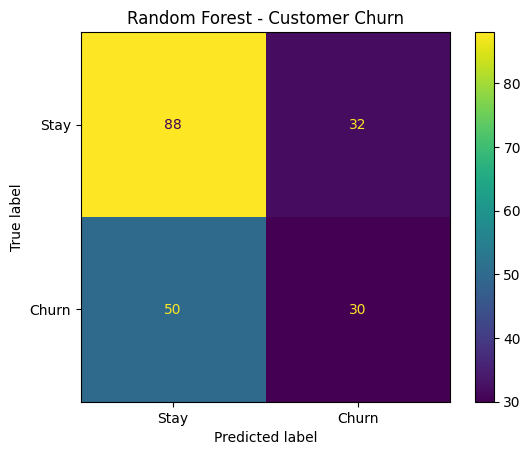

In [16]:
# ============================================
# 9. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stay", "Churn"]
)

disp.plot()
plt.title("Random Forest - Customer Churn")
plt.show()

Feature Importance:
MonthlyCharges    0.297718
Tenure            0.250099
Age               0.227828
SupportCalls      0.163524
ContractMonths    0.060831
dtype: float64


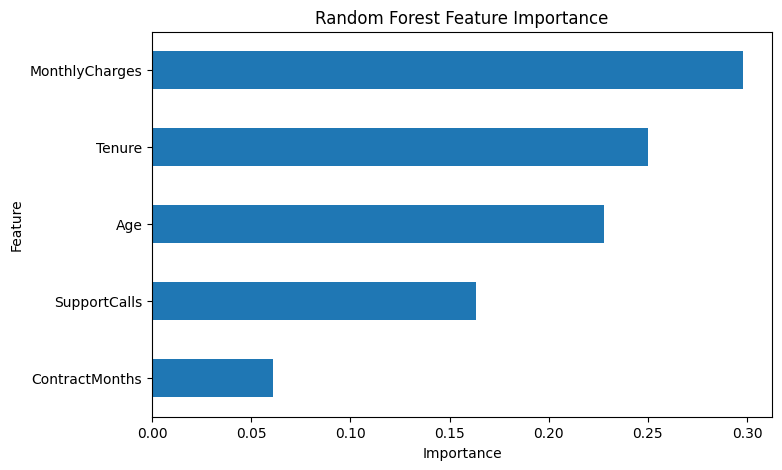

In [17]:
# ============================================
# 10. FEATURE IMPORTANCE
# ============================================

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.show()

In [18]:
# ============================================
# 11. PREDICT A NEW CUSTOMER
# ============================================

new_customer = pd.DataFrame({
    "Age": [30],
    "Tenure": [5],
    "MonthlyCharges": [120],
    "SupportCalls": [7],
    "ContractMonths": [1]
})

prediction = rf_model.predict(new_customer)[0]
probability = rf_model.predict_proba(new_customer)[0]

if prediction == 1:
    result = "Customer likely to churn"
else:
    result = "Customer likely to stay"

print("Prediction:", result)
print(f"Probability of staying : {probability[0]:.2%}")
print(f"Probability of churning: {probability[1]:.2%}")

Prediction: Customer likely to churn
Probability of staying : 21.00%
Probability of churning: 79.00%
